## Observer Design Pattern

Defines a one-to-many relationship between objects so that when one object changes state, all of its dependents are notified and updated automatically.

Observer is a behavioral design pattern that lets you define a subscription mechanism to notify multiple objects about any events that happen to the object they’re observing.

#### Applicability:
1. Use the Observer pattern when changes to the state of one object may require changing other objects, and the actual set of objects is unknown beforehand or changes dynamically.
2. Use the pattern when some objects in your app must observe others, but only for a limited time or in specific cases.

#### Use cases:
1. Notification service
2. News feed service
3. Event Handling

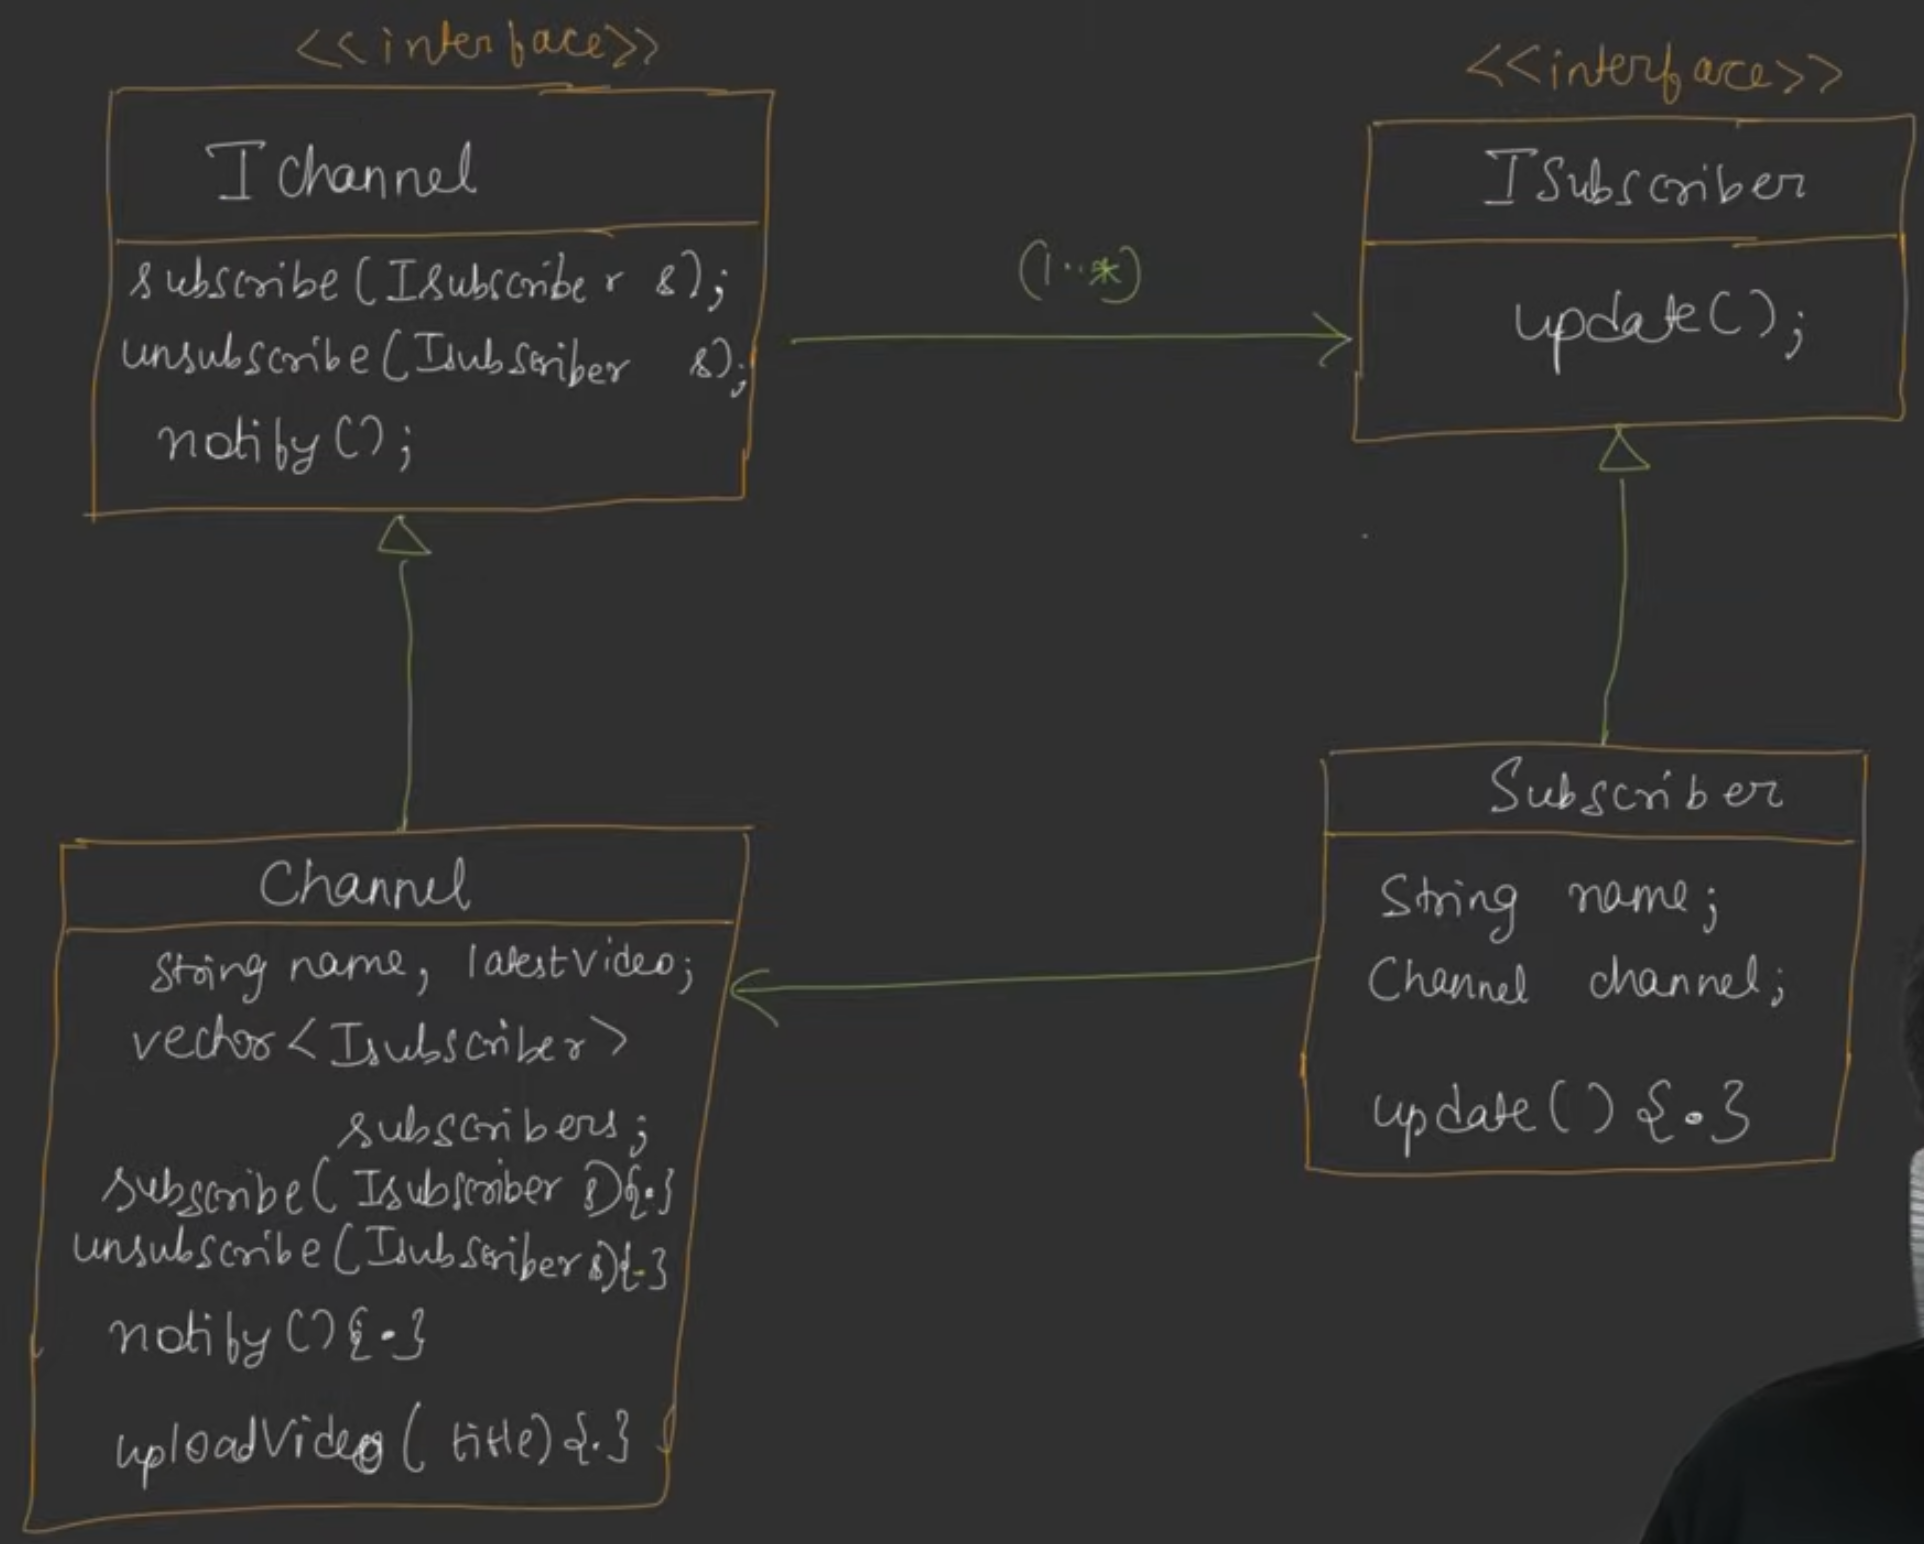

### Code

In [ ]:
from abc import ABC, abstractmethod

class ISubscriber(ABC):
    @abstractmethod
    def update(self) -> None:
        pass

class IChannel(ABC):
    @abstractmethod
    def subscribe(self, subscriber: "ISubscriber") -> None:
        pass
    @abstractmethod
    def unsubscribe(self, subscriber: "ISubscriber") -> None:
        pass
    @abstractmethod
    def notify_subscribers(self) -> None:
        pass

class Channel(IChannel):
    def __init__(self, name: str):
        self.name = name
        self.latest_video: str = ""
        self._subscribers: list[ISubscriber] = []

    def subscribe(self, subscriber: ISubscriber) -> None:
        if subscriber not in self._subscribers:
            self._subscribers.append(subscriber)

    def unsubscribe(self, subscriber: ISubscriber) -> None:
        self._subscribers.remove(subscriber)

    def notify_subscribers(self) -> None:
        for sub in self._subscribers:
            sub.update()

    def upload_video(self, title: str) -> None:
        self.latest_video = title
        print(f"\n[{self.name} uploaded \"{title}\"]")
        self.notify_subscribers()

    def get_video_data(self) -> str:
        return f"\nCheckout our new Video : {self.latest_video}\n"

class Subscriber(ISubscriber):
    def __init__(self, name: str, channel: Channel):
        self.name = name
        self.channel = channel

    def update(self) -> None:
        print(f"Hey {self.name},{self.channel.get_video_data()}")


if __name__ == "__main__":
    channel = Channel("CoderArmy")

    subs1 = Subscriber("Varun", channel)
    subs2 = Subscriber("Tarun", channel)

    channel.subscribe(subs1)
    channel.subscribe(subs2)

    channel.upload_video("Observer Pattern Tutorial")

    channel.unsubscribe(subs1)

    channel.upload_video("Decorator Pattern Tutorial")
